In [1]:
import os
import re
import pickle
from pathlib import Path
import numpy as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu

import modvis
import pyvista as pv
import ipywidgets as widgets
from IPython.display import display

from scipy.stats import mannwhitneyu
from datasources import DataSources
from knots_tools import *

In [2]:
ccds, _ = load_cknots_base_data(as_pyranges=False)
ccds = ccds.query('dataset == "GM12878"')
ccds

start        end  n_nodes  degree_min  \
dataset chromosome ccd_id                                              
GM12878 chr1       1          979903    1292598      144           1   
                   2         1396161    1444274       22           1   
                   3         2194421    2382994       70           1   
                   4         2414292    2550490       42           1   
                   5         2554288    2588242       14           1   
...                              ...        ...      ...         ...   
        chrX       47      153470312  153509407       10           1   
                   48      153548532  153671621       46           1   
                   49      153921716  153954431        6           1   
                   50      154396167  154528521       56           1   
                   51        2781305  155696236    52534           1   

                           degree_max  degree_mean  closeness_min  \
dataset chromosome ccd_id                                           
GM12878 chr1       1               31     3.833333       0.209064   
                   2                8     3.545455       0.344262   
                   3               15     3.285714       0.221154   
                   4               14     3.333333       0.262821   
                   5                5     3.000000       0.361111   
...                               ...          ...            ...   
        chrX       47               6     2.600000       0.409091   
                   48              17     3.434783       0.258621   
                   49               4     2.666667       0.500000   
                   50              18     3.142857       0.227273   
                   51              75     3.036205       0.053556   

                           closeness_max  closeness_mean  betweenness_min  \
dataset chromosome ccd_id                                                   
GM12878 chr1       1            0.486395        0.298816              0.0   
                   2            0.583333        0.435563              0.0   
                   3            0.489362        0.309287              0.0   
                   4            0.569444        0.359728              0.0   
                   5            0.565217        0.450216              0.0   
...                                  ...             ...              ...   
        chrX       47           0.750000        0.514207              0.0   
                   48           0.584416        0.354000              0.0   
                   49           0.833333        0.676918              0.0   
                   50           0.539216        0.317760              0.0   
                   51           0.134326        0.092281              0.0   

                           ...  distance_mean  edge_betweenness_min  \
dataset chromosome ccd_id  ...                                        
GM12878 chr1       1       ...   3.836444e+04          1.109141e-03   
                   2       ...   1.268756e+04          2.319625e-02   
                   3       ...   3.106717e+04          4.061915e-03   
                   4       ...   2.519097e+04          9.291521e-03   
                   5       ...   8.239524e+03          4.395604e-02   
...                        ...            ...                   ...   
        chrX       47      ...   1.073092e+04          4.444444e-02   
                   48      ...   2.316843e+04          9.710145e-03   
                   49      ...   9.522125e+03          1.000000e-01   
                   50      ...   1.835019e+04          1.948052e-03   
                   51      ...   1.632313e+06          1.449397e-09   

                           edge_betweenness_max  edge_betweenness_mean  \
dataset chromosome ccd_id                                                
GM12878 chr1       1                   0.052735               0.012451   
                   2                   0.131025 

In [3]:
bounds = ccds.query('has_minors')[['n_edges', 'length']].agg(['min', 'max']).T
bounds

,min,max
n_edges,143,7141
length,155163,6990086


In [4]:
bounds['min'] -= (bounds['min'] * 0.25).astype(int)
bounds['max'] += (bounds['max'] * 0.25).astype(int)
bounds

,min,max
n_edges,108,8926
length,116373,8737607


In [5]:
ccds[['n_edges', 'length']].agg(['min', 'max']).T

,min,max
n_edges,1,136611
length,12931,248334085


In [6]:
ccds_flt = ccds[ccds['n_edges'].between(bounds.loc['n_edges', 'min'], bounds.loc['n_edges', 'max']) &
                  ccds['length'].between(bounds.loc['length', 'min'], bounds.loc['length', 'max'])]
ccds_flt = ccds_flt.loc['GM12878']
ccds_flt

start        end  n_nodes  degree_min  degree_max  \
chromosome ccd_id                                                          
chr1       1          979903    1292598      144           1          31   
           3         2194421    2382994       70           1          15   
           9         6244361    6444698       72           1          20   
           10        6725436    6892305       80           1          19   
           13        7973345    8351848      174           1          42   
...                      ...        ...      ...         ...         ...   
chrX       40      119505387  119783093      108           1          35   
           42      129602594  130064069      208           1          35   
           43      131821091  132624207      336           1          47   
           44      133790635  134028788      104           1          20   
           45      136026827  136274387       88           1          29   

                   degree_mean  closeness_min  closeness_max  closeness_mean  \
chromosome ccd_id                                                              
chr1       1          3.833333       0.209064       0.486395        0.298816   
           3          3.285714       0.221154       0.489362        0.309287   
           9          3.722222       0.256318       0.546154        0.340169   
           10         3.675000       0.165618       0.475904        0.293583   
           13         3.540230       0.184043       0.475275        0.275944   
...                        ...            ...            ...             ...   
chrX       40         5.740741       0.243736       0.557292        0.348883   
           42         4.134615       0.223301       0.455947        0.293645   
           43         3.672619       0.137014       0.408039        0.248001   
           44         3.250000       0.201566       0.447826        0.277970   
           45         3.431818       0.226562       0.564935        0.330207   

                   betweenness_min  ...  distance_mean  edge_betweenness_min  \
chromosome ccd_id                   ...                                        
chr1       1                   0.0  ...   38364.438406              0.001109   
           3                   0.0  ...   31067.165217              0.004062   
           9                   0.0  ...   33408.753731              0.003620   
           10                  0.0  ...   19366.000000              0.000633   
           13                  0.0  ...   57571.831169              0.000642   
...                            ...  ...            ...                   ...   
chrX       40                  0.0  ...   48809.948387              0.000710   
           42                  0.0  ...   51550.581395              0.000232   
           43                  0.0  ...   77547.523501              0.000053   
           44                  0.0  ...   24081.289941              0.000373   
           45                  0.0  ...   41884.403974              0.001480   

                   edge_betweenness_max  edge_betweenness_mean  \
chromosome ccd_id                                                
chr1       1                   0.052735               0.012451   
           3                   0.132888               0.028906   
           9                   0.065767               0.022560   
           10                  0.211332               0.024122   
           13                  0.069806               0.012136   
...                                 ...                    ...   
chrX       40                  0.057346               0.009552   
           42                  0.054426               0.008104   
           43                  0.053297               0.006777   
           44                  0.137518               0.021880   
           45                  0.103363               0.020648   

                   n_edges_in_minors  edges_in_minors_ratio  n_minors  \
chromosome ccd_id   

# p_EV analysis

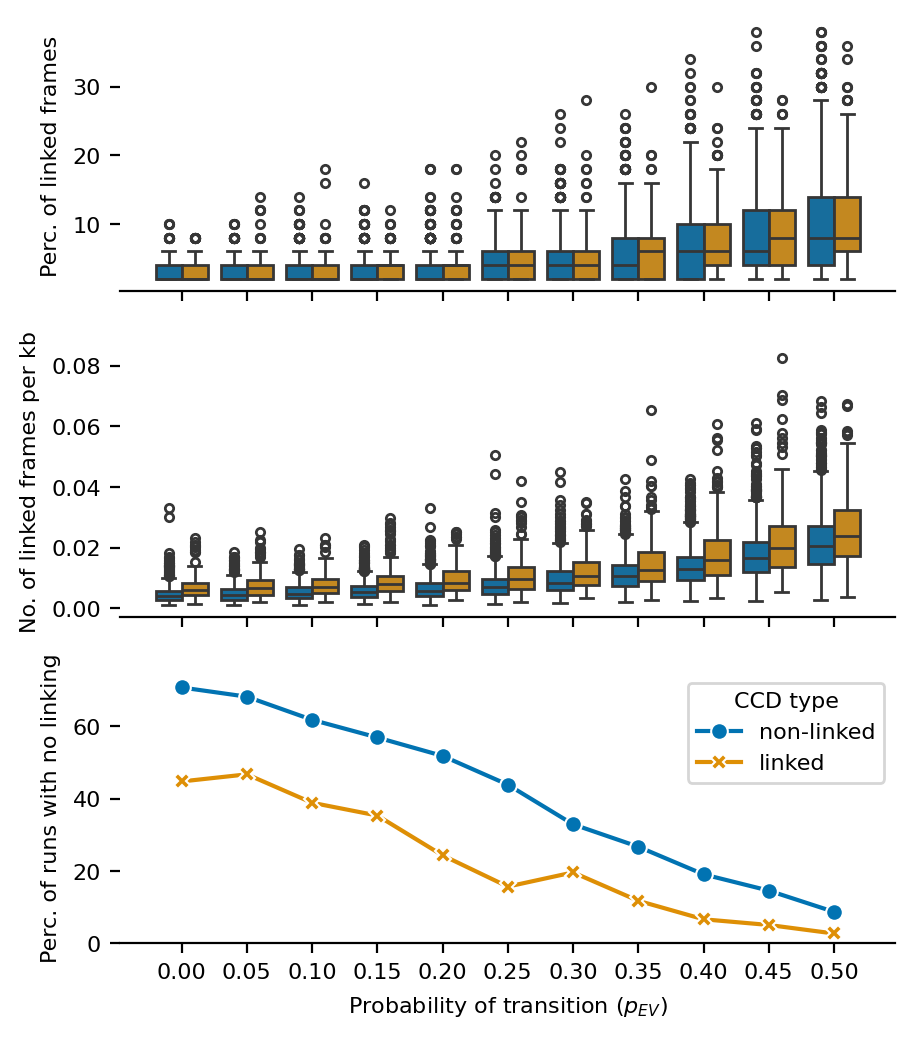

In [7]:
ccds_linking_df3 = pd.read_csv('./data/ccds_linking_numbers_exp3.csv')
ccds_linking_df3['perc_linked_frames'] = ccds_linking_df3['prop_linked_frames'] * 100.0
ccds_linking_df3['n_linked_frames_per_kb'] = ccds_linking_df3['n_linked_frames'] / ccds_linking_df3['n_edges']
ccds_linking_df3['has_linked_frames'] = ccds_linking_df3['n_linked_frames'] > 0

linking_tab = ccds_linking_df3.groupby(['has_minors', 'evp', 'has_linked_frames']).size().unstack('has_linked_frames')
linking_tab['total'] = linking_tab.sum(axis=1)
linking_tab['perc_no_links'] = 100.0 * (linking_tab[False] / linking_tab['total'])
linking_tab

matplotlib.rcParams.update({'font.size': 8})
fig, (ax_top, ax_mid, ax_bottom) = plt.subplots(
    3, 1, sharex=True, figsize=(5, 6), dpi=200,
    gridspec_kw={"height_ratios": [3, 3, 3], "hspace": 0.2}
)
evp_ticks = sorted(linking_tab.reset_index().evp.unique())

ccds_linking_df_haslinks = ccds_linking_df3[ccds_linking_df3.has_linked_frames]
# Top: boxplots

sns.boxplot(
    data=ccds_linking_df_haslinks,
    x="evp", y="n_linked_frames", hue="has_minors", ax=ax_top,
    native_scale=True, palette='colorblind', fliersize=3
)
ax_top.legend_.remove()
ax_top.set_ylabel('Perc. of linked frames');
ax_top.set_xticks(evp_ticks)

sns.boxplot(
    data=ccds_linking_df_haslinks,
    x="evp", y="n_linked_frames_per_kb", hue="has_minors", ax=ax_mid,
    native_scale=True, palette='colorblind', fliersize=3
)
ax_mid.legend_.remove()
ax_mid.set_ylabel('No. of linked frames per kb');
ax_mid.set_xticks(evp_ticks)

# Bottom: line plot
sns.lineplot(data=linking_tab, x="evp",
             y="perc_no_links", hue="has_minors", style="has_minors",
             palette='colorblind',
             markers=True, dashes=False, ax=ax_bottom)

# ax_bottom.invert_yaxis()
ax_bottom.set_xlabel('Probability of transition ($p_{EV}$)')
ax_bottom.set_ylabel('Perc. of runs with no linking');
ax_bottom.set_ylim(0, 75)
ax_bottom.set_xticks(evp_ticks)
handles, labels = ax_bottom.get_legend_handles_labels()
ax_bottom.legend(handles[:2], ["non-linked", "linked"], title="CCD type");

for ax in (ax_top, ax_mid, ax_bottom):
    ax.spines["left"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)

# plt.savefig('./results/svg/loopsage_pev.svg')

In [8]:
ccds_linking_df_haslinks.groupby(['evp', 'has_minors']).agg(
    avg_linked_frames=('perc_linked_frames', 'mean'),
    med_linked_frames=('perc_linked_frames', 'median'),
    avg_linked_frames_per_kb=('n_linked_frames_per_kb', 'mean'),
    med_linked_frames_per_kb=('n_linked_frames_per_kb', 'median')
).unstack('has_minors').sort_index(ascending=False)

mw_results = []
for evp, g in ccds_linking_df_haslinks.reset_index().groupby('evp'):
    row = {'evp': evp}    
    print(f'p_EV=={evp}:')
    for metric in ['perc_linked_frames', 'n_linked_frames_per_kb']:        
        grp_true = g.loc[g['has_minors'], metric].dropna()
        grp_false = g.loc[~g['has_minors'], metric].dropna()

        row[f'{metric}_n_true'] = len(grp_true)
        row[f'{metric}_n_false'] = len(grp_false)
        row[f'{metric}_median_true'] = grp_true.median()
        row[f'{metric}_median_false'] = grp_false.median()

        if len(grp_true) == 0 or len(grp_false) == 0:
            row[f'{metric}_u_stat'] = np.nan
            row[f'{metric}_pvalue'] = np.nan
        else:
            u_stat, pvalue = mannwhitneyu(grp_true, grp_false, alternative='two-sided')            
            row[f'{metric}_u_stat'] = u_stat
            row[f'{metric}_pvalue'] = pvalue
        print(f'metric:  {metric}: U={u_stat}, p-value={pvalue:.5f}, n_true={len(grp_true)}, n_false={len(grp_false)}')
        print(f'Median of non-linked CCDs: {grp_false.median():.2f}, Median of linked CCDs: {grp_true.median():.2f}')

    mw_results.append(row)

mw_results_df = pd.DataFrame(mw_results).set_index('evp').sort_index()
mw_results_df

p_EV==0.0:
metric:  perc_linked_frames: U=34330.0, p-value=0.08213, n_true=141, n_false=451
Median of non-linked CCDs: 4.00, Median of linked CCDs: 4.00
metric:  n_linked_frames_per_kb: U=46557.0, p-value=0.00000, n_true=141, n_false=451
Median of non-linked CCDs: 0.00, Median of linked CCDs: 0.01
p_EV==0.05:
metric:  perc_linked_frames: U=37690.0, p-value=0.00530, n_true=136, n_false=490
Median of non-linked CCDs: 4.00, Median of linked CCDs: 4.00
metric:  n_linked_frames_per_kb: U=47608.5, p-value=0.00000, n_true=136, n_false=490
Median of non-linked CCDs: 0.00, Median of linked CCDs: 0.01
p_EV==0.1:
metric:  perc_linked_frames: U=49118.0, p-value=0.12225, n_true=156, n_false=588
Median of non-linked CCDs: 4.00, Median of linked CCDs: 4.00
metric:  n_linked_frames_per_kb: U=62574.0, p-value=0.00000, n_true=156, n_false=588
Median of non-linked CCDs: 0.00, Median of linked CCDs: 0.01
p_EV==0.15:
metric:  perc_linked_frames: U=59672.0, p-value=0.04869, n_true=165, n_false=663
Median of

,perc_linked_frames_n_true,perc_linked_frames_n_false,perc_linked_frames_median_true,perc_linked_frames_median_false,perc_linked_frames_u_stat,perc_linked_frames_pvalue,n_linked_frames_per_kb_n_true,n_linked_frames_per_kb_n_false,n_linked_frames_per_kb_median_true,n_linked_frames_per_kb_median_false,n_linked_frames_per_kb_u_stat,n_linked_frames_per_kb_pvalue
evp,,,,,,,,,,,,
0.00,141,451,4.0,4.0,34330.0,0.082127,141,451,0.006006,0.003846,46557.0,8.300050e-17
0.05,136,490,4.0,4.0,37690.0,0.005302,136,490,0.006661,0.004219,47608.5,1.902431e-14
0.10,156,588,4.0,4.0,49118.0,0.122252,156,588,0.006975,0.004651,62574.0,2.522247e-12
0.15,165,663,8.0,4.0,59672.0,0.048689,165,663,0.007874,0.005300,76992.0,5.075550e-16
0.20,193,741,8.0,4.0,74762.0,0.288133,193,741,0.008264,0.005722,99201.5,1.072855e-16
0.25,215,863,8.0,8.0,96095.0,0.388998,215,863,0.009615,0.006826,122021.5,8.022693e-13
0.30,205,1031,8.0,8.0,114535.0,0.048496,205,1031,0.010563,0.008439,133803.0,1.685919e-09
0.35,225,1126,12.0,8.0,137209.0,0.043122,225,1126,0.012658,0.010444,157032.5,1.331269e-08
0.40,238,1243,12.0,12.0,158741.5,0.068957,238,1243,0.015969,0.012887,183272.5,4.940393e-09


# Case-control analysis for a set of CCDs

In [9]:
linking_numbers_df = pd.read_csv(
    os.path.join('./data/exp1_all_linking_numbers.csv'),
    dtype={'idx_loop_A': int, 'idx_loop_B': int, 'idx_start_A': int, 'idx_start_B': int, 'idx_end_A': int, 'idx_end_B': int}
)
linking_numbers_df = pd.merge(
    linking_numbers_df,
    ccds.reset_index()[['has_minors', 'chromosome', 'ccd_id', 'length', 'n_nodes', 'n_edges']],
    on=['chromosome', 'ccd_id'],
    how='left'
)
linking_numbers_df

,cell_line,chromosome,start,end,ccd_id,rep,frame,pair_idx,idx_loop_A,idx_loop_B,idx_start_A,idx_end_A,idx_start_B,idx_end_B,linking_number,abs_linking_number,has_minors,length,n_nodes,n_edges
0,GM12878,chr1,974903,1297598,1,1,3,0,16,18,197,211,212,230,0.876,0.876,True,312695,144,276
1,GM12878,chr1,974903,1297598,1,1,19,0,29,31,376,394,395,411,0.552,0.552,True,312695,144,276
2,GM12878,chr1,974903,1297598,1,1,38,0,23,35,314,410,458,490,0.903,0.903,True,312695,144,276
3,GM12878,chr1,974903,1297598,1,1,38,1,23,37,314,410,491,547,0.419,0.419,True,312695,144,276
4,GM12878,chr1,974903,1297598,1,1,38,2,31,35,391,409,458,490,0.904,0.904,True,312695,144,276
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149442,GM12878,chrX,129597594,130069069,42,9,247,0,13,17,136,196,197,253,1.160,1.160,False,461475,208,430
149443,GM12878,chrX,129597594,130069069,42,9,247,1,13,19,136,196,213,251,1.199,1.199,False,461475,208,430
149444,GM12878,chrX,129597594,130069069,42,9,247,2,14,17,140,156,197,253,0.966,0.966,False,461475,208,430
149445,GM12878,chrX,129597594,130069069,42,9,247,3,14,19,140,156,213,251,0.959,0.959,False,461475,208,430


In [10]:
LINKING_NUMBER_THRESHOLD = 0.9
frame_df = linking_numbers_df.groupby(
    ['cell_line', 'has_minors', 'chromosome', 'ccd_id', 'rep', 'frame']
).agg(
    n_links=('abs_linking_number',lambda x: (x > LINKING_NUMBER_THRESHOLD).sum())
)
frame_df = frame_df.sort_index()
frame_df = frame_df.n_links.unstack('frame', fill_value=0)
frame_df

frame                                       1    2    3    4    5    6    7    \
cell_line has_minors chromosome ccd_id rep                                      
GM12878   False      chr1       27     0      0    0    0    0    0    0    0   
                                       1      0    0    0    0    0    0    0   
                                       2      0    0    0    0    0    0    0   
                                       3      0    0    0    0    0    0    0   
                                       4      0    0    0    0    0    0    0   
...                                         ...  ...  ...  ...  ...  ...  ...   
          True       chr7       40     0      0    0    0    0    0    0    0   
                                       1      0    0    0    0    0    0    0   
                                       2      0    0    1    0    0    0    0   
                                       3      0    0    0    0    0    0    0   
                                       4      0    1    0    0    0    0    0   

frame                                       8    9    10   ...  240  241  242  \
cell_line has_minors chromosome ccd_id rep                 ...                  
GM12878   False      chr1       27     0      0    0    0  ...    0    0    0   
                                       1      0    0    0  ...    0    0    0   
                                       2      0    0    0  ...    0    0    0   
                                       3      0    0    0  ...    0    0    0   
                                       4      0    0    0  ...    0    0    0   
...                                         ...  ...  ...  ...  ...  ...  ...   
          True       chr7       40     0      3    0    0  ...    0    0    0   
                                       1      0    0    0  ...    0    0    0   
                                       2      0    0    0  ...    0    0    0   
                                       3      0    0    0  ...    0    0    0   
                                       4      1    0    0  ...    0    0    0   

frame                                       243  244  245  246  247  248  249  
cell_line has_minors chromosome ccd_id rep                                     
GM12878   False      chr1       27     0      0    0    0    0    0    0    0  
                                       1      0    0    0    1    0    0    0  
                                       2      0    0    0    0    0    0    0  
                                       3      0    0    0    0    0    0    0  
                                       4      0    0    0    0    0    0    0  
...                                         ...  ...  ...  ...  ...  ...  ...  
          True       chr7       40     0      0    0    0    0    0    0    0  
                                       1      0    0    0    0    0    0    0  
                                       2      0    0    0    0    0    0    0  
                                       3      0    0    0    0    0    0    0  
                                       4      0    0    0    0    0    0    0  

[4312 rows x 249 columns]

In [11]:
TOTAL_N_FRAMES = 250
rep_df = frame_df.sum(axis=1).to_frame('n_linked_frames')
rep_df['has_linked_frames'] = rep_df['n_linked_frames'] > 0
rep_df['prop_linked_frames'] = rep_df['n_linked_frames'] / TOTAL_N_FRAMES
rep_df

n_linked_frames  \
cell_line has_minors chromosome ccd_id rep                    
GM12878   False      chr1       27     0                  3   
                                       1                  4   
                                       2                  7   
                                       3                  1   
                                       4                  5   
...                                                     ...   
          True       chr7       40     0                 23   
                                       1                 15   
                                       2                 11   
                                       3                 12   
                                       4                  8   

                                            has_linked_frames  \
cell_line has_minors chromosome ccd_id rep                      
GM12878   False      chr1       27     0                 True   
                                       1                 True   
                                       2                 True   
                                       3                 True   
                                       4                 True   
...                                                       ...   
          True       chr7       40     0                 True   
                                       1                 True   
                                       2                 True   
                                       3                 True   
                                       4                 True   

                                            prop_linked_frames  
cell_line has_minors chromosome ccd_id rep                      
GM12878   False      chr1       27     0                 0.012  
                                       1                 0.016  
                                       2                 0.028  
                                       3                 0.004  
                                       4                 0.020  
...                                                        ...  
          True       chr7       40     0                 0.092  
                                       1                 0.060  
                                       2                 0.044  
                                       3                 0.048  
                                       4                 0.032  

[4312 rows x 3 columns]

In [15]:
agg_df = rep_df.groupby(['has_minors', 'chromosome', 'ccd_id'])\
    .agg(avg_linked_frames=('n_linked_frames', 'mean'))
agg_df = pd.merge(
    agg_df.reset_index(),
    ccds.reset_index()[['has_minors', 'chromosome', 'ccd_id', 'length']],
    on=['has_minors', 'chromosome', 'ccd_id'],
    how='left'
).set_index(['has_minors', 'chromosome', 'ccd_id'])
agg_df['avg_linked_frames_per_kb'] = 1000 * agg_df['avg_linked_frames'] / agg_df['length']
agg_df['perc_linked_frames'] = 100 * agg_df['avg_linked_frames'] / TOTAL_N_FRAMES
agg_df

avg_linked_frames   length  \
has_minors chromosome ccd_id                               
False      chr1       27               4.900000   222583   
                      31               6.500000   195780   
                      33               8.300000   282748   
                      34              14.500000   284879   
                      53               6.300000   188579   
...                                         ...      ...   
True       chr7       8               52.222222  1199084   
                      11              57.300000  1416087   
                      20              61.900000  1167241   
                      29              33.777778   837261   
                      40              13.800000   538247   

                              avg_linked_frames_per_kb  perc_linked_frames  
has_minors chromosome ccd_id                                                
False      chr1       27                      0.022014            1.960000  
                      31                      0.033201            2.600000  
                      33                      0.029355            3.320000  
                      34                      0.050899            5.800000  
                      53                      0.033408            2.520000  
...                                                ...                 ...  
True       chr7       8                       0.043552           20.888889  
                      11                      0.040464           22.920000  
                      20                      0.053031           24.760000  
                      29                      0.040343           13.511111  
                      40                      0.025639            5.520000  

[438 rows x 4 columns]

/tmp/ipykernel_528708/2978193784.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0].set_xticklabels(['non-linked', 'linked']);
/tmp/ipykernel_528708/2978193784.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[1].set_xticklabels(['non-linked', 'linked']);


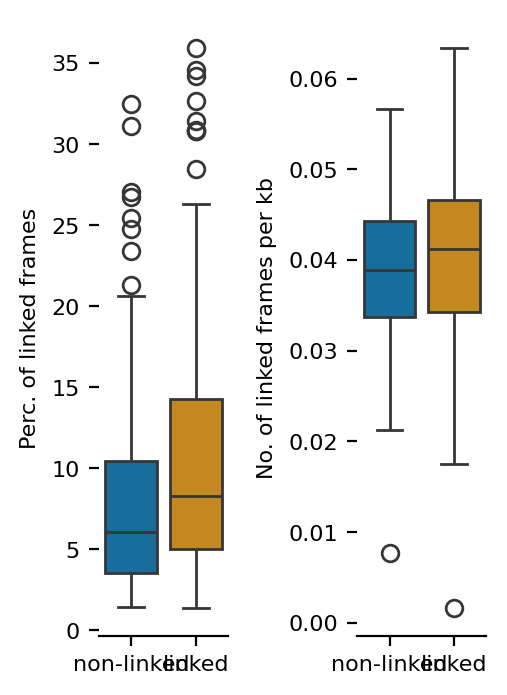

In [17]:
matplotlib.rcParams.update({'font.size': 8})
_, axs = plt.subplots(1, 2, figsize=(2.5, 4), dpi=200, sharey=False, gridspec_kw={"width_ratios": [1, 1], "wspace": 1})
sns.boxplot(data=agg_df, x='has_minors', hue='has_minors', y='perc_linked_frames', legend=False, palette='colorblind', ax=axs[0]).set(
    ylabel='Perc. of linked frames', xlabel=None);
axs[0].set_xticklabels(['non-linked', 'linked']);
sns.boxplot(data=agg_df, x='has_minors', hue='has_minors', y='avg_linked_frames_per_kb', legend=False, palette='colorblind', ax=axs[1]).set(
    ylabel='No. of linked frames per kb', xlabel=None);
axs[1].set_xticklabels(['non-linked', 'linked']);
for ax in axs:
    ax.spines["left"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
# plt.savefig('./results/svg/loopsage_exp1.svg')

In [18]:
frame_agg_df = agg_df.reset_index().copy()
_nl = frame_agg_df[frame_agg_df.has_minors == False]
_yl = frame_agg_df[frame_agg_df.has_minors == True]
for col in ['perc_linked_frames', 'avg_linked_frames_per_kb']:
    print(f'Performing Mann-Whitney U test on {col} between non-linked and linked CCDs....')
    stat, p_value = mannwhitneyu(_nl[col], _yl[col], alternative='two-sided')
    print(f'Group sizes: non-linked CCDs: {_nl.shape[0]}, linked CCDs: {_yl.shape[0]}')
    print(f'Median of non-linked CCDs: {_nl[col].median():.2f}, Median of linked CCDs: {_yl[col].median():.2f}')
    print(f'Mann-Whitney U test p-value: {p_value:.6f}, U statistic: {stat}')

Performing Mann-Whitney U test on perc_linked_frames between non-linked and linked CCDs....
Group sizes: non-linked CCDs: 224, linked CCDs: 214
Median of non-linked CCDs: 6.04, Median of linked CCDs: 8.26
Mann-Whitney U test p-value: 0.000024, U statistic: 18379.5
Performing Mann-Whitney U test on avg_linked_frames_per_kb between non-linked and linked CCDs....
Group sizes: non-linked CCDs: 224, linked CCDs: 214
Median of non-linked CCDs: 0.04, Median of linked CCDs: 0.04
Mann-Whitney U test p-value: 0.015689, U statistic: 20768.0
